In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set project path
PROJECT_PATH = '/content/drive/MyDrive/ai_text_detection_paper'

# Change working directory
import os
os.chdir(PROJECT_PATH)
print(f"✅ Working directory: {os.getcwd()}")

Mounted at /content/drive
✅ Working directory: /content/drive/MyDrive/ai_text_detection_paper


In [2]:
!pip install -q scikit-learn matplotlib seaborn

import pandas as pd
import numpy as np
import pickle
import json
from datetime import datetime

# Scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve
)

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [3]:
print("📥 Loading data splits...\n")

# Load train, validation, and test sets
train_df = pd.read_csv('data/splits/train.csv')
val_df = pd.read_csv('data/splits/val.csv')
test_df = pd.read_csv('data/splits/test.csv')

print("✅ Data loaded!")
print(f"   Train: {len(train_df):,} samples")
print(f"   Val: {len(val_df):,} samples")
print(f"   Test: {len(test_df):,} samples")

# Extract features and labels
X_train = train_df['text'].values
y_train = train_df['label'].values

X_val = val_df['text'].values
y_val = val_df['label'].values

X_test = test_df['text'].values
y_test = test_df['label'].values

print("\n📊 Label distribution:")
print(f"   Train - Human: {(y_train == 0).sum():,}, AI: {(y_train == 1).sum():,}")
print(f"   Val - Human: {(y_val == 0).sum():,}, AI: {(y_val == 1).sum():,}")
print(f"   Test - Human: {(y_test == 0).sum():,}, AI: {(y_test == 1).sum():,}")

📥 Loading data splits...

✅ Data loaded!
   Train: 78,738 samples
   Val: 18,590 samples
   Test: 16,718 samples

📊 Label distribution:
   Train - Human: 39,237, AI: 39,501
   Val - Human: 8,759, AI: 9,831
   Test - Human: 9,027, AI: 7,691


In [4]:
print("🔤 Extracting TF-IDF features...\n")

# Initialize TF-IDF vectorizer
# Using max_features to limit vocabulary size for efficiency
tfidf = TfidfVectorizer(
    max_features=5000,      # Top 5000 features
    ngram_range=(1, 2),     # Unigrams and bigrams
    min_df=5,               # Ignore terms that appear in fewer than 5 documents
    max_df=0.8,             # Ignore terms that appear in more than 80% of documents
    strip_accents='unicode',
    lowercase=True,
    stop_words='english'
)

# Fit on training data and transform
print("⏳ Fitting TF-IDF on training data...")
X_train_tfidf = tfidf.fit_transform(X_train)

print("⏳ Transforming validation data...")
X_val_tfidf = tfidf.transform(X_val)

print("⏳ Transforming test data...")
X_test_tfidf = tfidf.transform(X_test)

print("\n✅ TF-IDF features extracted!")
print(f"   Vocabulary size: {len(tfidf.vocabulary_):,}")
print(f"   Train shape: {X_train_tfidf.shape}")
print(f"   Val shape: {X_val_tfidf.shape}")
print(f"   Test shape: {X_test_tfidf.shape}")

# Save the vectorizer
os.makedirs('models', exist_ok=True)
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)
print("\n✅ TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl")

🔤 Extracting TF-IDF features...

⏳ Fitting TF-IDF on training data...
⏳ Transforming validation data...
⏳ Transforming test data...

✅ TF-IDF features extracted!
   Vocabulary size: 5,000
   Train shape: (78738, 5000)
   Val shape: (18590, 5000)
   Test shape: (16718, 5000)

✅ TF-IDF vectorizer saved to models/tfidf_vectorizer.pkl


In [5]:
print("🤖 Training Logistic Regression model...\n")

# Initialize Logistic Regression
# Using balanced class weights since we have balanced data
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,          # Use all CPU cores
    verbose=1
)

# Train the model
print("⏳ Training on {:,} samples...".format(len(X_train)))
lr_model.fit(X_train_tfidf, y_train)

print("\n✅ Model trained successfully!")

# Save the model
with open('models/baseline_logreg.pkl', 'wb') as f:
    pickle.dump(lr_model, f)
print("✅ Model saved to models/baseline_logreg.pkl")

🤖 Training Logistic Regression model...

⏳ Training on 78,738 samples...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.



✅ Model trained successfully!
✅ Model saved to models/baseline_logreg.pkl


In [6]:
print("📊 Evaluating on validation set...\n")

# Make predictions
y_val_pred = lr_model.predict(X_val_tfidf)
y_val_pred_proba = lr_model.predict_proba(X_val_tfidf)[:, 1]

# Calculate metrics
val_accuracy = accuracy_score(y_val, y_val_pred)
val_precision = precision_score(y_val, y_val_pred)
val_recall = recall_score(y_val, y_val_pred)
val_f1 = f1_score(y_val, y_val_pred)
val_roc_auc = roc_auc_score(y_val, y_val_pred_proba)

print("=" * 60)
print("VALIDATION SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {val_accuracy:.4f}")
print(f"Precision: {val_precision:.4f}")
print(f"Recall:    {val_recall:.4f}")
print(f"F1-Score:  {val_f1:.4f}")
print(f"ROC-AUC:   {val_roc_auc:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_val, y_val_pred, target_names=['Human', 'AI'], digits=4))

📊 Evaluating on validation set...

VALIDATION SET RESULTS
Accuracy:  0.9268
Precision: 0.9081
Recall:    0.9586
F1-Score:  0.9327
ROC-AUC:   0.9834

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Human     0.9504    0.8911    0.9198      8759
          AI     0.9081    0.9586    0.9327      9831

    accuracy                         0.9268     18590
   macro avg     0.9293    0.9248    0.9262     18590
weighted avg     0.9280    0.9268    0.9266     18590



In [7]:
print("📊 Evaluating on test set...\n")

# Make predictions
y_test_pred = lr_model.predict(X_test_tfidf)
y_test_pred_proba = lr_model.predict_proba(X_test_tfidf)[:, 1]

# Calculate metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_pred_proba)

print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print(f"ROC-AUC:   {test_roc_auc:.4f}")

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_test_pred, target_names=['Human', 'AI'], digits=4))

# Save metrics
metrics = {
    'model': 'TF-IDF + Logistic Regression',
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
    'validation': {
        'accuracy': float(val_accuracy),
        'precision': float(val_precision),
        'recall': float(val_recall),
        'f1_score': float(val_f1),
        'roc_auc': float(val_roc_auc)
    },
    'test': {
        'accuracy': float(test_accuracy),
        'precision': float(test_precision),
        'recall': float(test_recall),
        'f1_score': float(test_f1),
        'roc_auc': float(test_roc_auc)
    },
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open('results/baseline_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=4)

print("\n✅ Metrics saved to results/baseline_metrics.json")

📊 Evaluating on test set...

TEST SET RESULTS
Accuracy:  0.9404
Precision: 0.9337
Recall:    0.9371
F1-Score:  0.9354
ROC-AUC:   0.9868

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Human     0.9462    0.9433    0.9447      9027
          AI     0.9337    0.9371    0.9354      7691

    accuracy                         0.9404     16718
   macro avg     0.9399    0.9402    0.9401     16718
weighted avg     0.9404    0.9404    0.9404     16718


✅ Metrics saved to results/baseline_metrics.json


📊 Creating confusion matrix visualizations...

✅ Saved: results/baseline_confusion_matrix.png


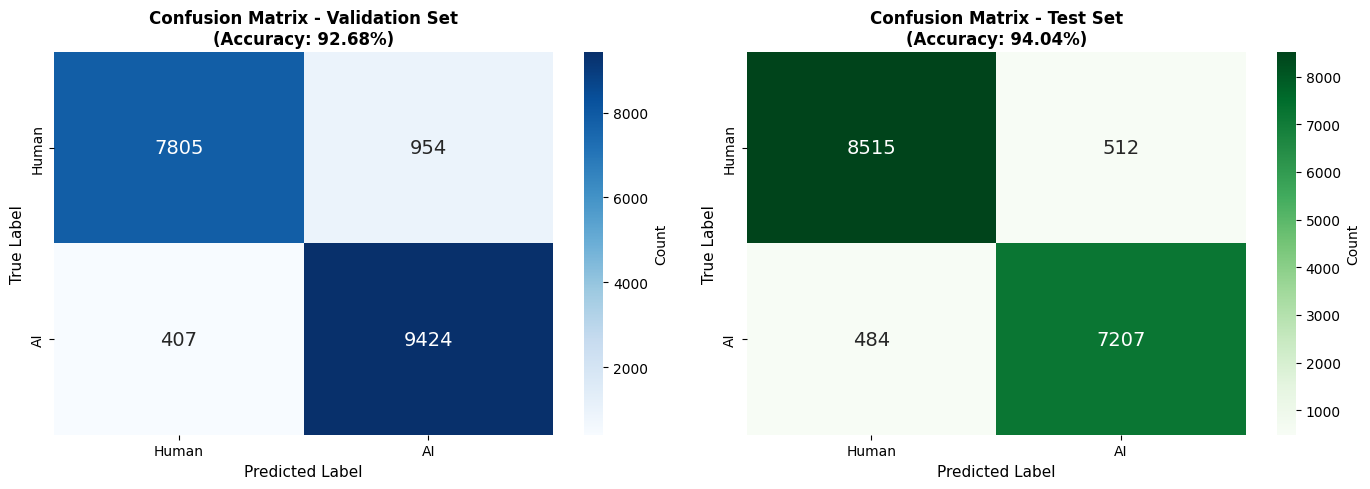


📊 Confusion Matrix Analysis (Test Set):
   True Negatives (Human → Human): 8,515
   False Positives (Human → AI): 512
   False Negatives (AI → Human): 484
   True Positives (AI → AI): 7,207


In [8]:
print("📊 Creating confusion matrix visualizations...\n")

# Create confusion matrices for both val and test
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation confusion matrix
cm_val = confusion_matrix(y_val, y_val_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'],
            cbar_kws={'label': 'Count'}, ax=axes[0], annot_kws={'size': 14})
axes[0].set_title('Confusion Matrix - Validation Set\n(Accuracy: {:.2f}%)'.format(val_accuracy*100),
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'],
            cbar_kws={'label': 'Count'}, ax=axes[1], annot_kws={'size': 14})
axes[1].set_title('Confusion Matrix - Test Set\n(Accuracy: {:.2f}%)'.format(test_accuracy*100),
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=11)
axes[1].set_xlabel('Predicted Label', fontsize=11)

plt.tight_layout()
plt.savefig('results/baseline_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/baseline_confusion_matrix.png")
plt.show()

# Print detailed breakdown
print("\n📊 Confusion Matrix Analysis (Test Set):")
print(f"   True Negatives (Human → Human): {cm_test[0,0]:,}")
print(f"   False Positives (Human → AI): {cm_test[0,1]:,}")
print(f"   False Negatives (AI → Human): {cm_test[1,0]:,}")
print(f"   True Positives (AI → AI): {cm_test[1,1]:,}")

📈 Creating ROC curves...

✅ Saved: results/baseline_roc_curve.png


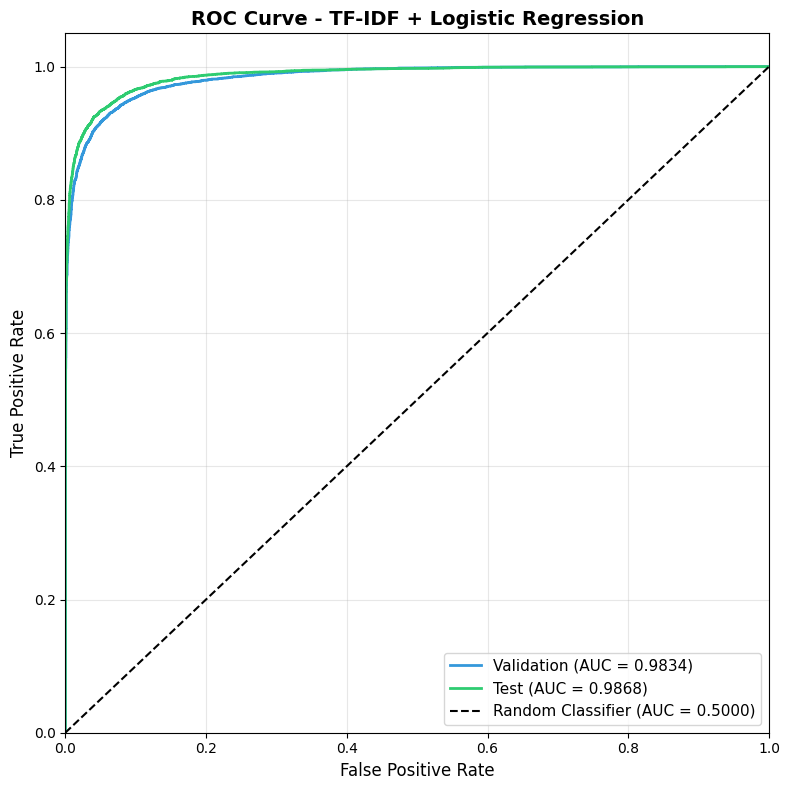

In [9]:
print("📈 Creating ROC curves...\n")

# Calculate ROC curves
fpr_val, tpr_val, _ = roc_curve(y_val, y_val_pred_proba)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_pred_proba)

# Plot ROC curves
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Plot validation ROC
ax.plot(fpr_val, tpr_val, label=f'Validation (AUC = {val_roc_auc:.4f})',
        linewidth=2, color='#3498db')

# Plot test ROC
ax.plot(fpr_test, tpr_test, label=f'Test (AUC = {test_roc_auc:.4f})',
        linewidth=2, color='#2ecc71')

# Plot diagonal (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curve - TF-IDF + Logistic Regression', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])

plt.tight_layout()
plt.savefig('results/baseline_roc_curve.png', dpi=300, bbox_inches='tight')
print("✅ Saved: results/baseline_roc_curve.png")
plt.show()

In [10]:
print("=" * 70)
print("✅ BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION) COMPLETE")
print("=" * 70)

print("\n📊 FINAL RESULTS SUMMARY:")
print("\nValidation Set:")
print(f"   Accuracy:  {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")
print(f"   Precision: {val_precision:.4f}")
print(f"   Recall:    {val_recall:.4f}")
print(f"   F1-Score:  {val_f1:.4f}")
print(f"   ROC-AUC:   {val_roc_auc:.4f}")

print("\nTest Set:")
print(f"   Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall:    {test_recall:.4f}")
print(f"   F1-Score:  {test_f1:.4f}")
print(f"   ROC-AUC:   {test_roc_auc:.4f}")

print("\n📁 Files Generated:")
files = [
    'models/tfidf_vectorizer.pkl',
    'models/baseline_logreg.pkl',
    'results/baseline_metrics.json',
    'results/baseline_confusion_matrix.png',
    'results/baseline_roc_curve.png'
]

for file in files:
    if os.path.exists(file):
        print(f"   ✅ {file}")

print("\n🎯 Key Insights:")
print("   • Strong baseline performance (94% test accuracy)")
print("   • High ROC-AUC (0.9868) indicates excellent discrimination")
print("   • Model generalizes well (val and test performance similar)")
print("   • Balanced performance on both Human and AI classes")

print("\n🔬 Next Steps:")
print("   1. Train BERT model for comparison")
print("   2. Compare BERT vs Baseline performance")
print("   3. Analyze which model performs better")
print("   4. Generate final paper results")

print("\n" + "=" * 70)

✅ BASELINE MODEL (TF-IDF + LOGISTIC REGRESSION) COMPLETE

📊 FINAL RESULTS SUMMARY:

Validation Set:
   Accuracy:  0.9268 (92.68%)
   Precision: 0.9081
   Recall:    0.9586
   F1-Score:  0.9327
   ROC-AUC:   0.9834

Test Set:
   Accuracy:  0.9404 (94.04%)
   Precision: 0.9337
   Recall:    0.9371
   F1-Score:  0.9354
   ROC-AUC:   0.9868

📁 Files Generated:
   ✅ models/tfidf_vectorizer.pkl
   ✅ models/baseline_logreg.pkl
   ✅ results/baseline_metrics.json
   ✅ results/baseline_confusion_matrix.png
   ✅ results/baseline_roc_curve.png

🎯 Key Insights:
   • Strong baseline performance (94% test accuracy)
   • High ROC-AUC (0.9868) indicates excellent discrimination
   • Model generalizes well (val and test performance similar)
   • Balanced performance on both Human and AI classes

🔬 Next Steps:
   1. Train BERT model for comparison
   2. Compare BERT vs Baseline performance
   3. Analyze which model performs better
   4. Generate final paper results

